In [1]:
import numpy as np

In [2]:
crew_and_payload = {
    "W_crew"    : 200,  # Crew weight, LBS
    "n_aim9x"   : 2,    # Number of AIM-9xs carried
    "n_mk83"    : 4,    # Number of MK-83s carried
    "n_aim120"  : 0,    # Number of AIM-120Cs carried
    "m_aim9x"   : 190,  # Weight AIM-9X, LBS
    "m_aim120"  : 360,  # Weight AIM-190C, LBS
    "m_mk83"    : 1000, # Weight MK-83 JDAM, LBS
    "avionics"  : 2500,    # Avionics weight, LBS
}

performance = {
    "M_cruise"  : 0.85,     # Cruise mach speed
    "h_cruise"  : 35000,    # Cruise altitude, FT
    "a_cruise"  : 972.6,    # Speed of sound at cruise, FT/s
    "R_cruise"  : 700,      # Cruise distance (Combat Radius), Nautical Miles
    "E_loiter"  : 20,       # Loiter time, min
    "M_dash"    : 0.85,     # Dash mach speed
    "a_dash"    : 1116,     # Speed of sound at SL, FT/s
    "R_dash"    : 100,      # Dash distnace, Nautical Miles
    "C_cruise"  : 0.8,      # Engine SFC in Cruise, 1/hr
    "C_dash"    : 1.0,      # Engine SFC in Dash (Max-non-afterburning), 1/hr
    "C_loiter"  : 0.7,      # Engine SFC in Loiter, 1/hr
    "C_after"   : 1.8,      # Engine SFC with Afterburner, 1/hr
    "E_combat"  : 2,        # Combat time, min
    "AR"        : 2.85,        # Estimated Aspect Ratio
    "Swet_Sref" : 4.3,        # Guess of Wetted Area Ratio
    "K_LD"      : 14,       # Factor in calculating L/D_max
}

mission_sequence = [1, 2, 3, 4, 5, 2, 3, 4, 7, 8]
# The above is the sequence of: TO, Climb, Cruise, Descent, SL Dash, Climb, Cruise, Descent, Loiter, Land. (The Strike mission)

#mission_sequence = [1, 2, 3, 6, 4, 7, 8]
# The above is the sequence of: TO, Cimb, Cruise, Combat, Descent, Loiter, Land. (Combat Mission)

#mission_sequence = [1, 2, 4, 2, 4, 2, 7, 4, 8]
# the above is the sequence of: TO, Climb, Descent, Climb, Descent, Climb, Loiter, Descent, Land

empty_statistic = {
    "A": 2.34,
    "C": -0.13,
    "MTOW_guess": 40000 
}

In [3]:
def crew_payload_mass(W_crew, n_aim9x, n_mk83, n_aim120, m_aim9x, m_aim120, m_mk83, avionics):
    W_payload = (n_aim9x * m_aim9x) + (n_mk83 * m_mk83) + (n_aim120 * m_aim120)
    W_crew_payload = W_crew + W_payload + avionics
    return W_crew_payload
    
W_crew_payload = crew_payload_mass(**crew_and_payload)
W_crew_payload

7080

In [4]:
def fuel_frac(mission_sequence, A, C, MTOW_guess):
    # Fixed Fuel Fractions
    ff_to = 0.970
    ff_climb = 0.985
    ff_descent = 0.99
    ff_land = 0.995


    # Cruise Fuel Fraction
    def cruise_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
               AR, Swet_Sref, K_LD):
        R_cruise_ft = R_cruise * 6076.12
        V_cruise = M_cruise * a_cruise

        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        LD_cruise = 0.866 * LD_max

        C_cruise_s = C_cruise / 3600

        wf_cruise = np.exp((-R_cruise_ft * C_cruise_s) / (V_cruise * LD_cruise))
        
        return wf_cruise
    
    ff_cruise = cruise_wf(**performance)


    # Dash Fuel Fraction
    def dash_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
             AR, Swet_Sref, K_LD):
        V_dash = M_dash * a_dash
        R_dash_ft = R_dash * 6076.12
        C_dash_s = C_dash / 3600
        
        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        LD_dash = 0.700 * LD_max

        wf_dash = np.exp((-R_dash_ft * C_dash_s) / (V_dash * LD_dash))    
        return wf_dash
    
    ff_dash = dash_wf(**performance)


    # Loiter Fuel Fraction
    def loiter_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
               AR, Swet_Sref, K_LD):
        E_loiter_s = E_loiter * 60
        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        C_loiter_s = C_loiter / 3600

        wf_loiter = np.exp((-E_loiter_s * C_loiter_s) / LD_max)
        return wf_loiter
    
    ff_loiter = loiter_wf(**performance)


    # Combat Fuel Fraction
    def combat_wf(M_cruise, h_cruise, a_cruise, R_cruise, E_loiter, M_dash, a_dash, R_dash, C_cruise, C_dash, C_loiter, C_after, E_combat,
               AR, Swet_Sref, K_LD):
        E_combat_s = E_combat * 60
        C_after_s = C_after / 3600
        LD_max = K_LD * np.sqrt(AR / Swet_Sref)
        LD_combat = LD_max * 0.2

        wf_combat = np.exp((-E_combat_s * C_after_s) / LD_combat)
        return wf_combat
    
    ff_combat = combat_wf(**performance)

    # mid mission fuel fraction keeps track of the fuel fraction mid-mission, after descent stages
    MMF = np.empty(2)

    ## Combined Mission Fuel Fraction
    CFF = 0
    counter = 0
    for i, m_seq in enumerate(mission_sequence):
        if m_seq == 1:
            #print(f"Takeoff Fuel Fraction is: {ff_to}")
            CFF = ff_to
        if m_seq == 2:
            #print(f"Climb Fuel Fraction is: {ff_climb}")
            CFF = CFF * ff_climb
        if m_seq == 3:
            #print(f"Cruise Fuel Fraction is: {np.round(ff_cruise, 3)}")
            CFF = CFF * ff_cruise
            MMF[counter] = CFF
            counter = counter + 1
            #print(f"Mid mission fuel fraction is: {np.round(MMF, 3)}")
        if m_seq == 4:
            #print(f"Descent Fuel Fraction is: {ff_descent}")
            CFF = CFF * ff_descent
        if m_seq == 5:
            #print(f"SL Dash Fuel Fraction is: {np.round(ff_dash, 3)}")
            CFF = CFF * ff_dash
        if m_seq == 6:
            #print(f"Combat Fuel Fraction is: {np.round(ff_combat, 3)}")
            CFF = CFF * ff_combat
        if m_seq == 7:
            #print(f"Loiter Fuel Fraction is: {np.round(ff_loiter, 3)}")
            CFF = CFF * ff_loiter
        if m_seq == 8:
            #print(f"Landing Fuel Fraction is: {ff_land}")
            CFF = CFF * ff_land

        TFF = 1.06 * (1 - CFF)

    return TFF

fuel_fraction = fuel_frac(mission_sequence=mission_sequence, **empty_statistic)
fuel_fraction

np.float64(0.3206366285780029)

In [5]:
def empty_weight(S: dict, T_0, TOGW,):

    Engine_parts = {
        'dry': 0.521 * T_0**0.9,
        'oil': 0.082 * T_0**0.65,
        'rev': 0.034 * T_0,
        'control': 0.26 * T_0**0.5,
    }

    W_pneumatics = 9.33 * (Engine_parts['dry']/1000)**1.078
    W_engine = sum(Engine_parts.values()) + W_pneumatics

    Weight = {
        'wing': 9 * S['wing'],
        'htail':  4 * S['htail'],
        'vtail': 5.3 * S['vtail'], 
        'fuse': 4.8 * S['fuse_wet'], 
        'landing_gear': 0.045 * TOGW,
        'installed_engine': 1.3 * W_engine,
        'misc': 0.17 * TOGW
    }
    
    W_empty = sum(Weight.values())
    return W_empty

## Inner Loop

In [19]:
def weight_convergence(W_guess, T_0, S,
                       fuel_fraction = fuel_fraction,
                       W_crew_payload = W_crew_payload,
                       tol=1e-6, iter=200):
    delta = np.inf 
    i = 0
    converge_history = []

    while delta > tol and i < iter:
        W_fuel = W_guess * fuel_fraction
        W_empty = empty_weight(S, T_0, TOGW=W_guess)
        W_total = W_crew_payload + W_fuel + W_empty

        delta = abs(W_total - W_guess) / max(abs(W_total), 1e-9)
        converge_history.append((i, W_total))
        W_guess = W_total
        i +=1
    converged = (delta <= tol)

    return W_guess, converged, converge_history

a test here to show that the inner loop converges

In [36]:
_, converged, _ = weight_convergence(60000, 44000, S={'wing': 425.3, 'htail': 78.41, 'vtail': 78.41, 'fuse_wet':529.81})
converged

np.True_

## Outer Loop

In [26]:
def thrust_from_wing_area(W_guess, S_wing, T_0, segment_function, relax=1.0, tol =1e-3, max_iter=100):
    
    S = {'wing': S_wing, 'htail': 78.41, 'vtail': 78.41, 'fuse_wet':529.81}
    T_total = T_0

    for k in range(max_iter):
        W_0, converged, converge_history = weight_convergence(W_guess, T_0, S)

        WS = W_0 / S_wing
        TW = segment_function(WS)
        T_req = TW * W_0

        # Store history
        # T_hist.append(T_total)

        # Check outer convergence
        if abs(T_req - T_total) / max(abs(T_total), 1e-9) < tol:
            T_total = T_req
            break

        # Update thrust (optionally relaxed damping)
        T_total = (1 - relax) * T_total + relax * T_req
    return T_total

In [22]:
from ambiance import Atmosphere # this package is in metric units

a = lambda h: Atmosphere(h*0.3048).speed_of_sound * 3.2808399 # converts m/s to ft/s
rho = lambda h: Atmosphere(h*0.3047).density * 0.00194 # converts from kg/m-3 to slugs/ft-3


CLmax = {
    'takeoff': 1.7,
    'approach': 2.0
}

AERO_DEF = {
    'AR' : 2.85,
    'e' : 0.825,
    'c_Do' :  0.01378,
}

In [37]:
def dash(WL, Ma=0.85, alt=0, a=a, rho=rho,
         e=AERO_DEF['e'], AR=AERO_DEF['AR'], c_Do=AERO_DEF['c_Do'], 
         plot_styling={},fill=True):
    a = a(alt); rho = rho(alt)
    V = Ma * a
    q = 1/2 * rho * V**2 # dynamic pressure
    k = 1/ (np.pi*e*AR)
    TW = q* c_Do / WL + k/q * WL

    if not plot_styling:
        return TW
    else:
      if fill==True:
         plt.fill_between(WL, TW, 0, color='gainsboro')
      return plt.plot(WL, TW, label=f"Ma {Ma} dash, {alt/1000:.0f}k ft", **plot_styling)

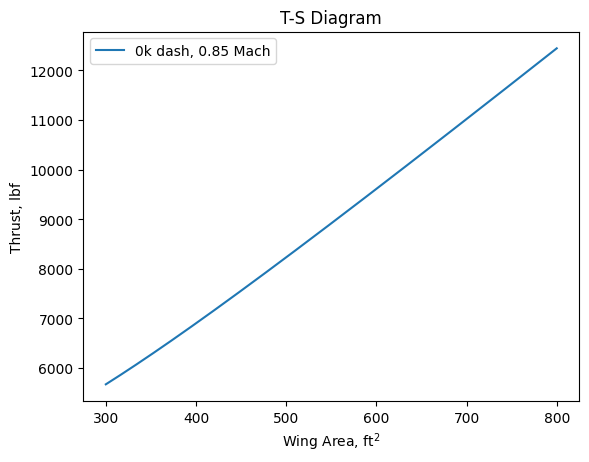

In [39]:
dash_pts = []
for S_guess in np.linspace(300, 800, 400):
    T  = thrust_from_wing_area(W_guess=60000, S_wing=S_guess, T_0=43000,segment_function=dash)
    dash_pts.append((S_guess, T))


plt.plot([x[0] for x in dash_pts], [x[1] for x in dash_pts], label='0k dash, 0.85 Mach')
plt.xlabel('Wing Area, ft$^2$')
plt.ylabel('Thrust, lbf')
plt.title('T-S Diagram')
plt.legend()